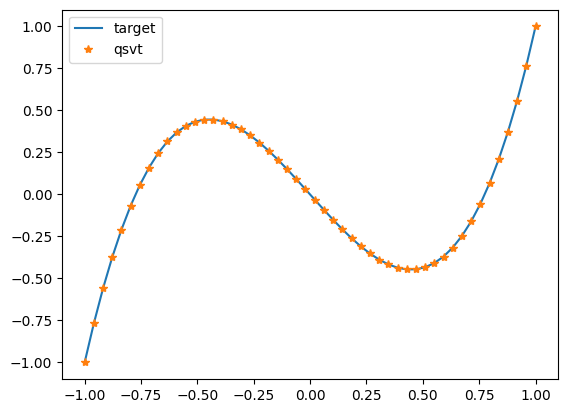

In [1]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt


target_poly = [0, -3 * 0.5, 0, 5 * 0.5]


def qsvt_output(a):
    # output matrix
    out = qml.matrix(qml.qsvt(a,  target_poly, encoding_wires=[0], block_encoding="embedding"))
    return out[0, 0]  # top-left entry


a_vals = np.linspace(-1, 1, 50)
qsvt = [np.real(qsvt_output(a)) for a in a_vals]  # neglect small imaginary part
target = [np.polyval(target_poly[::-1], a) for a in a_vals]  # evaluate polynomial

plt.plot(a_vals, target, label="target")
plt.plot(a_vals, qsvt, "*", label="qsvt")

plt.legend()
plt.show()

In [2]:
# square matrix
A = [[0.1, 0.2], [0.3, 0.4]]
U1 = qml.BlockEncode(A, wires=range(2))
print("U(A):")
print(np.round(qml.matrix(U1), 2))

U(A):
[[ 0.1   0.2   0.97 -0.06]
 [ 0.3   0.4  -0.06  0.86]
 [ 0.95 -0.08 -0.1  -0.3 ]
 [-0.08  0.89 -0.2  -0.4 ]]


In [3]:
B = [[0.5, -0.5, 0.5]]
U2 = qml.BlockEncode(B, wires=range(2))
print("U(B):")
print(np.round(qml.matrix(U2), 2))

U(B):
[[ 0.5  -0.5   0.5   0.5 ]
 [ 0.83  0.17 -0.17 -0.5 ]
 [ 0.17  0.83  0.17  0.5 ]
 [-0.17  0.17  0.83 -0.5 ]]


In [4]:
dim = 2
phi = np.pi / 2
pcp = qml.PCPhase(phi, dim, wires=range(2))
print("Pi:")
print(np.round(qml.matrix(pcp), 2))

Pi:
[[0.+1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+1.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.-1.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.-1.j]]


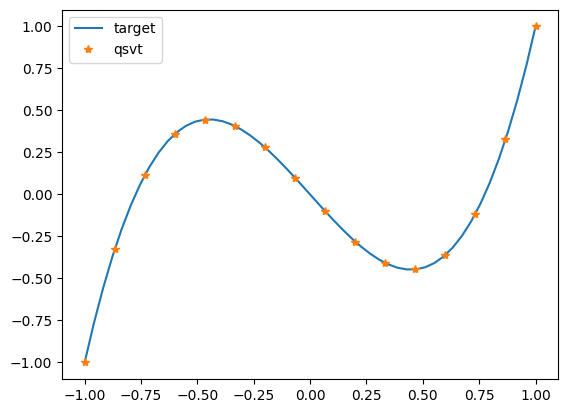

In [5]:
eigvals = np.linspace(-1, 1, 16)
A = np.diag(eigvals)  # 16-dim matrix
wire_order = list(range(5))
U_A = qml.matrix(qml.qsvt, wire_order=wire_order)(
    A, target_poly, encoding_wires=wire_order, block_encoding="embedding"
)  # block-encoded in 5-qubit system

qsvt_A = np.real(np.diagonal(U_A))[:16]  # retrieve transformed eigenvalues

plt.plot(a_vals, target, label="target")
plt.plot(eigvals, qsvt_A, "*", label="qsvt")

plt.legend()
plt.show()